In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew, kurtosis
from tabulate import tabulate

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Wczytanie danych Airbnb
df_airbnb = pd.read_csv("./data/airbnb_gotowy.csv")


df_airbnb.head(3)

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,...,number_of_stays,5_stars,listing_added,District,Neighborhood,longitude,latitude,visited,price_log,price_cut
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private room,45.0,10,2018-12-12,0.7,85,...,12.0,0.609432,2018-06-08,Brooklyn,Flatlands,40.63222,-73.93398,True,3.828641,"(0, 100]"
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire home/apt,135.0,1,2019-06-30,1.0,145,...,1.2,0.746135,2018-12-25,Manhattan,Upper West Side,40.78761,-73.96862,True,4.912655,"(100, 200]"
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Entire home/apt,150.0,0,NaN,0.0,65,...,NaN,NaN,2018-08-15,Brooklyn,Brooklyn Heights,40.70070,-73.99517,False,5.017280,"(100, 200]"


# 1. Skale pomiarowe (Measurement scales)
- **Skala nominalna**: np. rodzaj pokoju (`room_type`), dzielnica (`Neighborhood`).
- **Skala przedziałowa/ilorazowa**: np. cena (`price`), liczba recenzji (`number_of_reviews`), ocena (`rating`).

In [10]:
# Analiza częstotliwości dla skali nominalnej (Typ pokoju)
print(df_airbnb["room_type"].value_counts())

# Unikalne wartości dla innej zmiennej kategorycznej
print(df_airbnb["Neighborhood"].unique()[:10]) # pokazujemy 10 pierwszych

room_type
Entire home/apt    5173
Private room       4598
Shared room         226
Name: count, dtype: int64
<ArrowStringArray>
[        ' Flatlands',   ' Upper West Side',  ' Brooklyn Heights',
   ' Lower East Side', ' Greenwich Village',            ' Harlem',
    ' Sheepshead Bay',  ' Theater District',          ' Bushwick',
         ' Laurelton']
Length: 10, dtype: str


In [11]:
# Podsumowanie numeryczne dla wybranych kolumn
df_airbnb[["price", "number_of_reviews", "rating", "availability_365"]].describe()

,price,number_of_reviews,rating,availability_365
count,9997.000000,9997.000000,7927.000000,9997.000000
mean,149.633940,22.470741,4.014293,112.327798
std,202.455415,43.192920,0.574977,131.647306
min,10.000000,0.000000,3.000633,0.000000
25%,69.000000,1.000000,3.520212,0.000000
50%,105.000000,5.000000,4.028807,44.000000
75%,177.000000,22.000000,4.515814,226.000000
max,8000.000000,510.000000,5.181114,365.000000


# 2. Miary tendencji centralnej (Central tendency)
Średnia (mean), Mediana (median) oraz Dominanta (mode).

In [12]:
# Obliczanie średniej dla ocen i cen
print("Średnia cena (pandas):", df_airbnb['price'].mean())
print("Średnia ocena (scipy):", stats.tmean(df_airbnb['rating'].dropna()))

# Obliczanie mediany
print("Mediana ceny:", df_airbnb['price'].median())

# Obliczanie dominanty (Mode) dla zmiennej kategorycznej
print("Dominanta typu pokoju:\n", df_airbnb['room_type'].mode())

Średnia cena (pandas): 149.63394018205463
Średnia ocena (scipy): 4.014292725764674
Mediana ceny: 105.0
Dominanta typu pokoju:
 0    Entire home/apt
Name: room_type, dtype: str


In [13]:
# Średnia cena tylko dla ofert z Manhattanu
manhattan_mean = df_airbnb[df_airbnb["District"] == "Manhattan"]["price"].mean()
print("Średnia cena na Manhattanie:", manhattan_mean)

Średnia cena na Manhattanie: 192.91167192429023


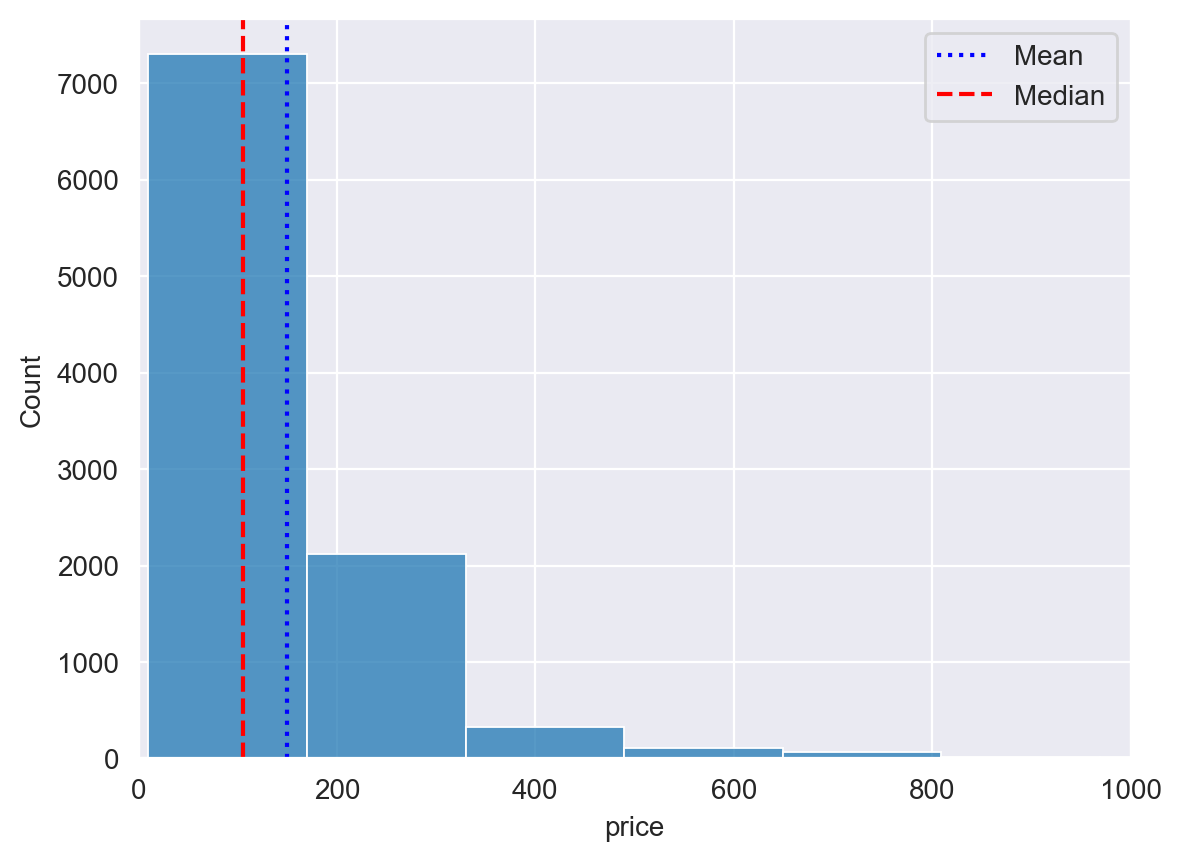

In [14]:
# Wizualizacja wpływu skośności na średnią i medianę
sns.histplot(data=df_airbnb, x="price", bins=50)
plt.axvline(df_airbnb['price'].mean(), linestyle="dotted", color="blue", label="Mean")
plt.axvline(df_airbnb['price'].median(), linestyle="dashed", color="red", label="Median")
plt.xlim(0, 1000) # ograniczenie osi X, aby lepiej widzieć rozkład z pominięciem ekstremalnych outlierów
plt.legend()
plt.show()

In [15]:
# Suma odchyleń od średniej (powinna być bardzo bliska 0)
prices = df_airbnb['price'].dropna().values
avg_price = np.mean(prices)
sum_of_deviations = np.sum(prices - avg_price)
print("Suma odchyleń od średniej:", round(sum_of_deviations, 5))

Suma odchyleń od średniej: -0.0


# 3. Kwantyle (Quantiles)
Kwartyle (Q1, Q3), decyle i percentyle.

In [16]:
# Odrzucamy braki danych dla ceny
s_price = df_airbnb['price'].dropna()

# Kwartyle
q1 = s_price.quantile(0.25)
median = s_price.quantile(0.5)
q3 = s_price.quantile(0.75)

# Decyle i percentyle
d1 = s_price.quantile(0.1)
d9 = s_price.quantile(0.9)
p95 = s_price.quantile(0.95)

print(f"Kwartyle - Q1: {q1}, Mediana: {median}, Q3: {q3}")
print(f"Decyle - D1 (10%): {d1}, D9 (90%): {d9}")
print(f"Percentyle - P95 (95%): {p95}")

Kwartyle - Q1: 69.0, Mediana: 105.0, Q3: 177.0
Decyle - D1 (10%): 50.0, D9 (90%): 260.0
Percentyle - P95 (95%): 350.0


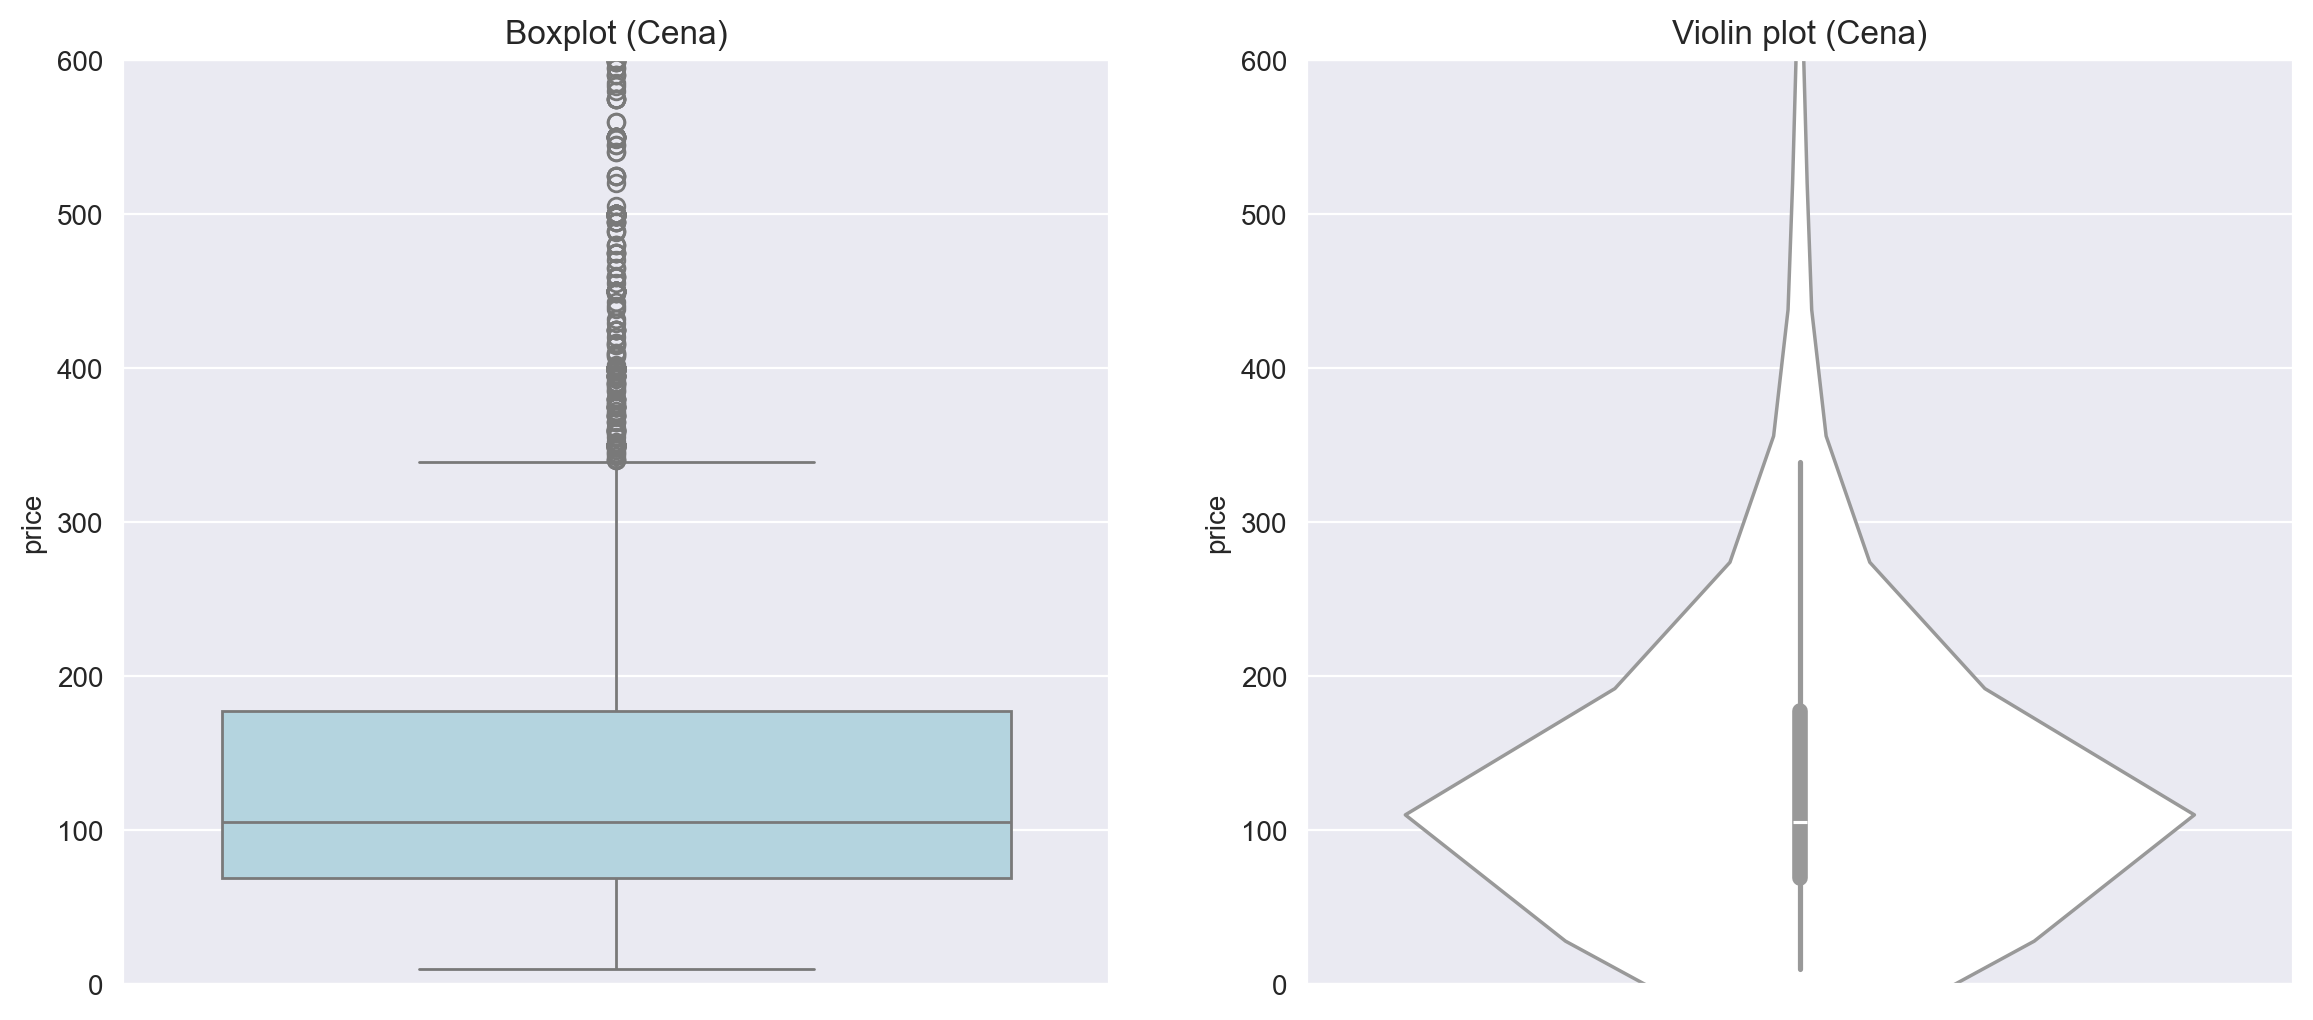

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(data=df_airbnb, y='price', ax=axes[0], color='lightblue')
axes[0].set_ylim(0, 600)
axes[0].set_title("Boxplot (Cena)")

# Violin plot
sns.violinplot(data=df_airbnb, y='price', ax=axes[1], color='white')
axes[1].set_ylim(0, 600)
axes[1].set_title("Violin plot (Cena)")

plt.show()

# 4. Zmienność (Variability/Dispersion)
Rozstęp (Range), Rozstęp międzykwartylowy (IQR), Wariancja, Odchylenie Standardowe (SD) oraz Współczynnik Zmienności (CV).

In [18]:
# Wariancja i odchylenie standardowe dla próby (scipy)
var_sample = stats.tvar(prices)
std_sample = stats.tstd(prices)

# CV (Współczynnik zmienności)
cv_sample = (std_sample / avg_price) * 100

print(f"Średnia cena: {avg_price:.2f}")
print(f"Wariancja próby: {var_sample:.2f}")
print(f"Odchylenie standardowe (SD): {std_sample:.2f}")
print(f"Współczynnik zmienności (CV): {cv_sample:.2f}%")

Średnia cena: 149.63
Wariancja próby: 40988.19
Odchylenie standardowe (SD): 202.46
Współczynnik zmienności (CV): 135.30%


In [19]:
# Analiza odchylenia standardowego, średniej i odchylenia ćwiartkowego (IQR deviation) dla typu pokoju
grouped_stats = df_airbnb[["room_type", "price"]].groupby("room_type").agg(
    ["std", "mean", lambda x: (x.quantile(0.75) - x.quantile(0.25)) / 2]
)
# Zmiana nazwy niestandardowej funkcji
grouped_stats.rename(columns={'<lambda_0>': 'IQR_deviation'}, inplace=True)
print(grouped_stats)

                      price                          
                        std        mean IQR_deviation
room_type                                            
Entire home/apt  249.546188  207.885946          52.5
Private room     101.704013   87.956068          21.0
Shared room      127.409692   71.126106          20.0


# 5. Kształt rozkładu (Skewness & Kurtosis)
Skośność (asymetria) i Kurtoza (intensywność wartości skrajnych/ogonów).

In [20]:
# Skośność i nadwyżka kurtozy (Excess Kurtosis) dla ceny
skewness = skew(prices)
excess_kurt = kurtosis(prices) # domyślnie fisher=True, co daje excess kurtosis

print(f"Skośność (Skewness) dla ceny: {skewness:.4f}")
print(f"Nadwyżka Kurtozy (Excess Kurtosis) dla ceny: {excess_kurt:.4f}")

Skośność (Skewness) dla ceny: 14.7164
Nadwyżka Kurtozy (Excess Kurtosis) dla ceny: 380.7249


In [21]:
# IQR Skewness
p10 = s_price.quantile(0.10)
p90 = s_price.quantile(0.90)

iqr_skewness = ((q3 - median) - (median - q1)) / (q3 - q1)
iqr_kurtosis = (q3 - q1) / (2 * (p90 - p10))

print(f"IQR Skewness: {iqr_skewness:.4f}")
print(f"IQR Kurtosis: {iqr_kurtosis:.4f}")

IQR Skewness: 0.3333
IQR Kurtosis: 0.2571


In [22]:
# Funkcja z Exercise8.ipynb
def markdown_summary(df, round_decimals=3):
    summary = df.describe().T
    summary['Skewness'] = df.skew()
    summary['Kurtosis'] = df.kurt()
    summary = summary.round(round_decimals)
    return tabulate(summary, headers='keys', tablefmt='github')

quantitative = df_airbnb.select_dtypes(include='number')
print(markdown_summary(quantitative))

|                   |   count |          mean |           std |      min |           25% |           50% |           75% |            max |   Skewness |   Kurtosis |
|-------------------|---------|---------------|---------------|----------|---------------|---------------|---------------|----------------|------------|------------|
| listing_id        |    9997 |   1.92736e+07 |   1.09503e+07 | 3831     |   9.67023e+06 |   2.00666e+07 |   2.93203e+07 |    3.64872e+07 |     -0.12  |     -1.216 |
| host_id           |    9997 |   6.80038e+07 |   7.86503e+07 | 2787     |   7.91066e+06 |   3.16615e+07 |   1.07434e+08 |    2.74103e+08 |      1.197 |      0.14  |
| price             |    9997 | 149.634       | 202.455       |   10     |  69           | 105           | 177           | 8000           |     14.719 |    380.916 |
| number_of_reviews |    9997 |  22.471       |  43.193       |    0     |   1           |   5           |  22           |  510           |      3.627 |     17.856 |
| re

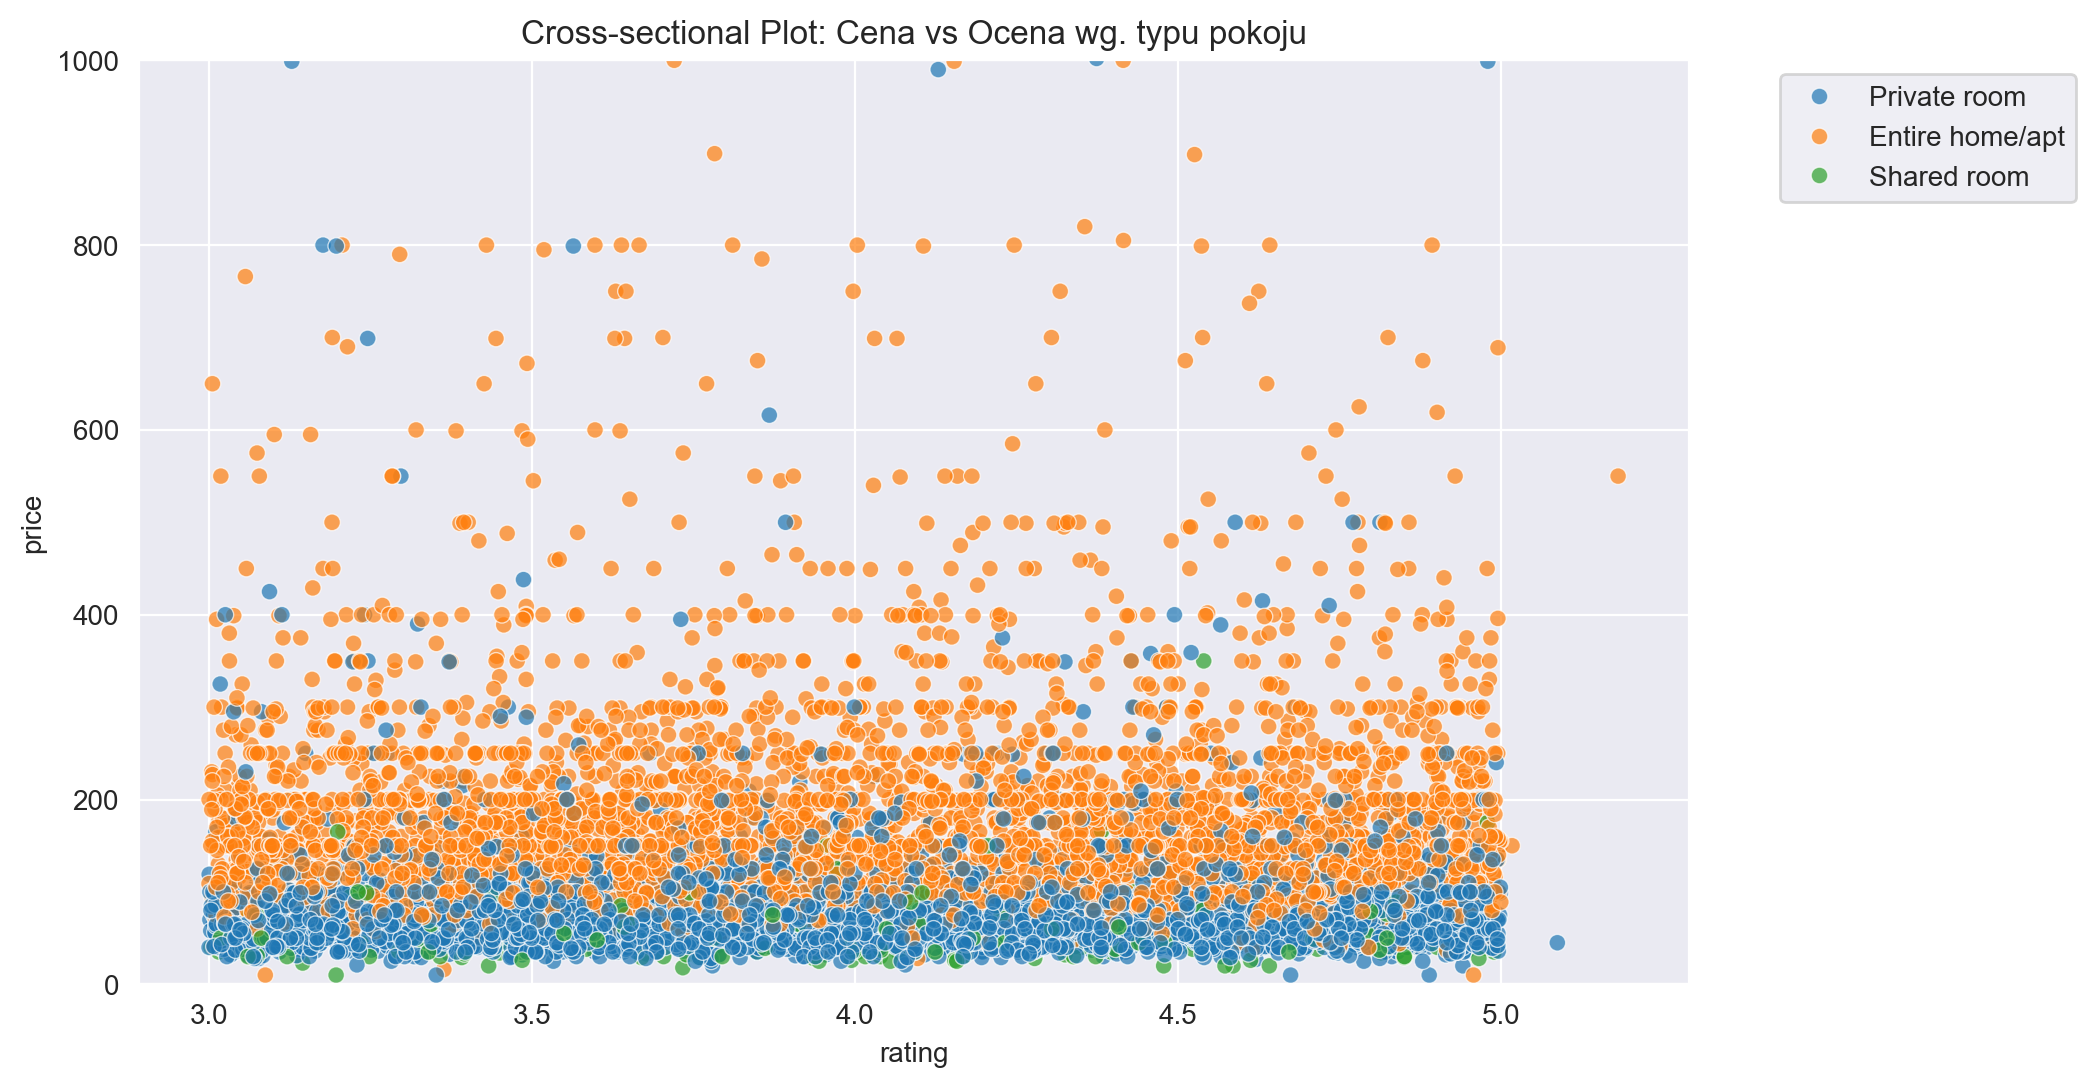

In [23]:
# Wykres punktowy: Ocena vs Cena z podziałem na typ pokoju
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_airbnb, x='rating', y='price', hue='room_type', alpha=0.7)
plt.title("Cross-sectional Plot: Cena vs Ocena wg. typu pokoju")
plt.ylim(0, 1000) # dla czytelności
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()